# Student Model

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
import warnings
warnings.filterwarnings('ignore')

# DATA LOAD -  DATA CLean

In [2]:
df = pd.read_csv('Student_Marks.csv')


In [3]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [4]:
df.shape

(100, 3)

# EDA

In [5]:
col =['number_courses','time_study','Marks']

In [6]:
df_clean =df[col]

In [7]:
df_clean.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [8]:
df_clean.isna().sum()

number_courses    0
time_study        0
Marks             0
dtype: int64

number_courses , time_study , 

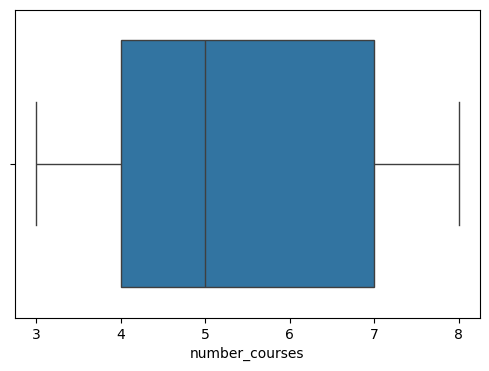

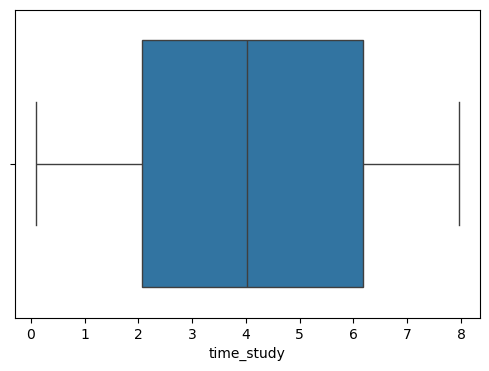

In [9]:
col =['number_courses','time_study']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

In [10]:
df_clean.duplicated().sum()

np.int64(0)

In [11]:
df_clean.dtypes

number_courses      int64
time_study        float64
Marks             float64
dtype: object

In [12]:
df_clean.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


<Axes: >

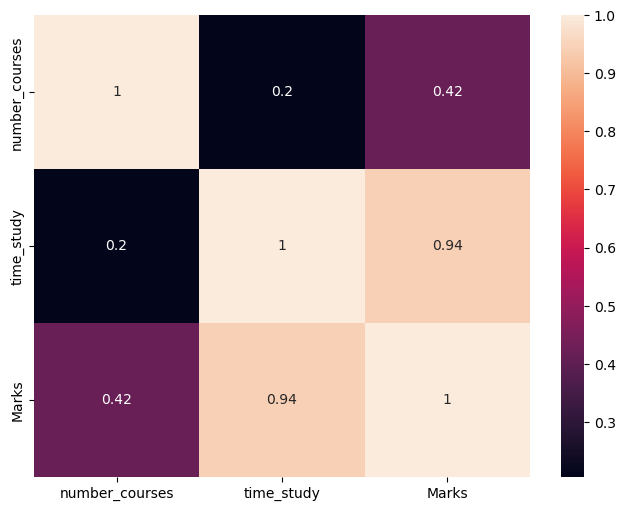

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

# Regression Model

In [14]:
df_clean

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


In [15]:
df_clean['result'] = df_clean['Marks'].apply(lambda x: True if x >= 30 else False)

In [16]:
df_clean

,number_courses,time_study,Marks,result
0,3,4.508,19.202,False
1,4,0.096,7.734,False
2,4,3.133,13.811,False
3,6,7.909,53.018,True
4,8,7.811,55.299,True
...,...,...,...,...
95,6,3.561,19.128,False
96,3,0.301,5.609,False
97,4,7.163,41.444,True
98,7,0.309,12.027,False


Linear Regression slope (Coefficients): [1.87154988 5.16987176]
Linear Regression Intercept: -7

Predicted Marks for user input: 21.55
Result: Fail

--- Linear Regression Test Metrics (Capped) ---
Mean Squared Error: 14.20
Root Mean Squared Error: 3.77
R2 Score: 0.9460

--- Decision Tree Regressor Test Metrics (Capped) ---
Mean Squared Error: 8.74
Root Mean Squared Error: 2.96
R2 Score: 0.9668


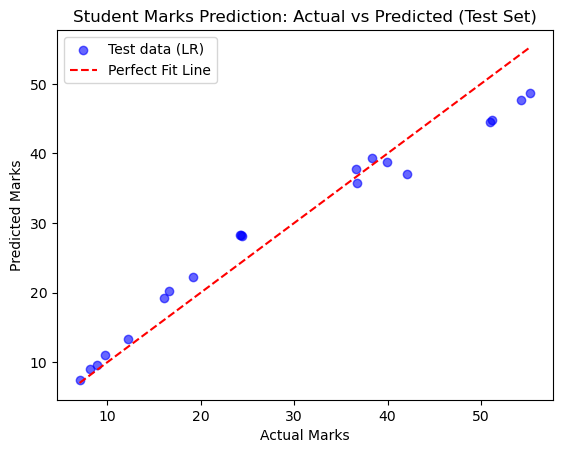

In [17]:
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.tree import DecisionTreeRegressor 

X = df_clean[['number_courses', 'time_study']]
y = df_clean["Marks"]

# 1. Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Models (Linear Regression & Decision Tree)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

print("Linear Regression slope (Coefficients):" , lr_model.coef_)
print("Linear Regression Intercept:" , round(lr_model.intercept_))

# 3. Non-blocking user input section
try:
    number_courses_in = input("Enter number of courses: ")
    number_courses = int(number_courses_in) if number_courses_in else 4
    time_study_in = input("Enter number of study hours: ")
    time_study = float(time_study_in) if time_study_in else 4.0
except:
    number_courses, time_study = 4, 4.0

predicted_marks = lr_model.predict([[number_courses, time_study]])[0]
predicted_marks = np.clip(predicted_marks, 0, 60)
result = "Pass" if predicted_marks >= 30 else "Fail"

print(f"\nPredicted Marks for user input: {predicted_marks:.2f}")
print(f"Result: {result}")

# 4. Evaluate Models on Test Set
lr_preds = lr_model.predict(X_test)
lr_preds_clipped = np.clip(lr_preds, 0, 60)
lr_mse = mean_squared_error(y_test, lr_preds_clipped)
lr_r2 = r2_score(y_test, lr_preds_clipped)

dt_preds = dt_model.predict(X_test)
dt_preds_clipped = np.clip(dt_preds, 0, 60)
dt_mse = mean_squared_error(y_test, dt_preds_clipped)
dt_r2 = r2_score(y_test, dt_preds_clipped)

print(f"\n--- Linear Regression Test Metrics (Capped) ---")
print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(lr_mse):.2f}")
print(f"R2 Score: {lr_r2:.4f}")

print(f"\n--- Decision Tree Regressor Test Metrics (Capped) ---")
print(f"Mean Squared Error: {dt_mse:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(dt_mse):.2f}")
print(f"R2 Score: {dt_r2:.4f}")

# 5. Plotting actual vs predicted on test set
plt.scatter(y_test, lr_preds_clipped, label="Test data (LR)", color="blue", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit Line')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Student Marks Prediction: Actual vs Predicted (Test Set)")
plt.legend()
plt.show()


In [18]:
df_clean['Marks'].max()

55.299

In [19]:
df_clean['Marks'].min()

5.609

In [20]:
# SAve the FIle

In [21]:
# Yeh aapke notebook wale folder me 'student_marks_cleaned.csv' naam se save kar dega
df_clean.to_csv('student_marks_cleaned.csv', index=False)